# Scorecard: which areas fit my business best?

**Business question:** Notebooks 01 to 08 each looked at one thing: who can pay, who needs care, who lives alone, who speaks Spanish, who has no car, who is offline. Put side by side, which areas come out on top, and does the answer hold if I weigh the measures differently?

**Why it matters:** I have limited time for outreach. This turns eight separate answers into one short list of where to start.

**Data:** `data/census_by_zip.csv` (notebook 00), plus the result files that notebooks 02 and 04 saved in `outputs/`.

**How to run:** Run notebooks 00, 02 and 04 first. Then run these cells top to bottom. No Census key needed.

In [1]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 250)

def load(path, notebook):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Run notebook {notebook} first. It creates {path[3:]}.")
    return pd.read_csv(path, dtype={"zip": str}).set_index("zip")

table = load("../data/census_by_zip.csv", "00_get_data")
care_vs_assistant = load("../outputs/care_vs_assistant.csv", "02_care_vs_assistant")
living_alone = load("../outputs/living_alone.csv", "04_living_alone")
N = len(table)
print(N, "ZIP code areas loaded")

24 ZIP code areas loaded


## 1. Six measures, one place for each

Each measure is a count taken from an earlier notebook. For each measure, every area gets a **place** from 1st (the most) to 24th (the fewest).

Nothing is multiplied together here. The Census does not say how many people are, for example, both living alone and able to pay, so the scorecard keeps the measures side by side.

In [2]:
RATE, MIN_HOURS, BUDGET_SHARE = 35, 4, 0.12
INCOME_LINE = RATE * MIN_HOURS * 52 / BUDGET_SHARE   # income at which a weekly visit is comfortable (notebook 05)

def bracket_start(col):
    return int(re.search(r"(\d+)k", col).group(1)) * 1000

bracket_cols = sorted([c for c in table.columns if c.startswith("hh65_income_from_")], key=bracket_start)
edges = [bracket_start(c) for c in bracket_cols]

def households_at_or_above(income):
    # Older households with at least this income (same method as notebook 05)
    total = 0
    for i, col in enumerate(bracket_cols):
        lo = edges[i]
        hi = edges[i + 1] if i + 1 < len(edges) else float("inf")
        if income <= lo:
            total = total + table[col]
        elif income < hi:
            total = total + table[col] * (hi - income) / (hi - lo)
    return total

# measure: (short name, what it counts, the numbers)
MEASURES = {
    "can_pay":   ("Can pay",    "Older households that can afford a weekly visit (notebook 05)", households_at_or_above(INCOME_LINE)),
    "care_need": ("Care need",  "People 65+ with difficulty bathing or dressing (notebook 02)",  table["selfcare_65plus"]),
    "alone":     ("Live alone", "People 65+ who live alone (notebook 04)",                       table["live_alone_65plus"]),
    "no_car":    ("No car",     "Older households with no car (notebook 07)",                    table["hh65_no_vehicle"]),
    "offline":   ("Offline",    "People 65+ with no computer or internet at home (notebook 08)", table["no_computer_65plus"] + table["computer_no_internet_65plus"]),
    "spanish":   ("Spanish",    "People 65+ who speak Spanish at home (notebook 06)",            table["spanish_65plus"]),
}

s = table[["area"]].copy()
for key, (_, _, values) in MEASURES.items():
    s[key] = values.round(0).astype(int)
    s[f"{key}_place"] = values.rank(ascending=False, method="min").astype(int)
    s[f"{key}_points"] = (N - s[f"{key}_place"]) / (N - 1) * 100    # 1st place = 100 points, last place = 0

for key, (name, meaning, _) in MEASURES.items():
    print(f"{name:11s} {meaning}")
s[["area"] + [f"{k}_place" for k in MEASURES]].sort_values("can_pay_place")

Can pay     Older households that can afford a weekly visit (notebook 05)
Care need   People 65+ with difficulty bathing or dressing (notebook 02)
Live alone  People 65+ who live alone (notebook 04)
No car      Older households with no car (notebook 07)
Offline     People 65+ with no computer or internet at home (notebook 08)
Spanish     People 65+ who speak Spanish at home (notebook 06)


,area,can_pay_place,care_need_place,alone_place,no_car_place,offline_place,spanish_place
zip,,,,,,,
94611,"Oakland, Montclair / Piedmont",1,14,2,5,12,14
94501,"Alameda, main island",2,1,1,4,1,5
94605,"Oakland, East Oakland hills",3,13,8,12,5,4
94610,"Oakland, Grand Lake",4,15,3,8,10,9
94602,"Oakland, Glenview / Dimond",5,4,6,11,7,7
94618,"Oakland, Rockridge",6,16,10,15,17,18
94707,"Berkeley, north hills",7,19,17,21,18,19
94705,"Berkeley, Claremont / Elmwood",8,20,18,19,19,21
94708,Berkeley hills,9,18,20,23,23,16


## 2. Do the measures tell the same story?

A link score compares two measures across the areas. Near 1 means areas that place high on one also place high on the other. Near 0 means no connection.

Age 75+ is left out of the scorecard because notebook 03 showed it ranks areas almost exactly like the count of people 65+.

In [3]:
NEED = ["care_need", "alone", "no_car", "offline"]
places = s[[f"{k}_place" for k in MEASURES]]
links = places.corr()

need_links = [links.loc[f"{a}_place", f"{b}_place"] for i, a in enumerate(NEED) for b in NEED[i + 1:]]
print(f"The four need measures (care need, live alone, no car, offline) are closely linked to each other: "
      f"scores from {min(need_links):.2f} to {max(need_links):.2f}.")
for k in NEED:
    print(f"   Link between 'can pay' and '{MEASURES[k][0].lower()}': {links.loc['can_pay_place', f'{k}_place']:.2f}")

# So the scorecard really has two sides: need and ability to pay
s["need_points"] = s[[f"{k}_points" for k in NEED]].mean(axis=1)
s["need_place"] = s["need_points"].rank(ascending=False, method="min").astype(int)
print(f"\nCombining the four need measures into one 'need' place:")
print(f"   Link between need and ability to pay: {s['need_place'].corr(s['can_pay_place']):.2f}")
print("   The areas with the most need are mostly not the areas with the most ability to pay.")

The four need measures (care need, live alone, no car, offline) are closely linked to each other: scores from 0.73 to 0.87.
   Link between 'can pay' and 'care need': 0.07
   Link between 'can pay' and 'live alone': 0.43
   Link between 'can pay' and 'no car': 0.01
   Link between 'can pay' and 'offline': 0.13

Combining the four need measures into one 'need' place:
   Link between need and ability to pay: 0.18
   The areas with the most need are mostly not the areas with the most ability to pay.


## 3. A verdict for each area

"High" means in the top third of areas (8 of 24). Each area gets one of four verdicts from its place on need and on ability to pay.

In [4]:
CUT = N // 3

def verdict(row):
    pay, need = row["can_pay_place"] <= CUT, row["need_place"] <= CUT
    if pay and need:
        return "Best fit"
    if pay:
        return "Can pay, less need"
    if need:
        return "Need, tight budgets"
    return "Lower priority"
s["verdict"] = s.apply(verdict, axis=1)

ORDER = ["Best fit", "Can pay, less need", "Need, tight budgets", "Lower priority"]
for label in ORDER[:3]:
    rows = s[s["verdict"] == label].sort_values("can_pay_place" if label != "Need, tight budgets" else "need_place")
    print(f"{label} ({len(rows)}):")
    for z, row in rows.iterrows():
        print(f"   {z}  {row['area']}: place {row['can_pay_place']} for can pay, {row['need_place']} for need, {row['spanish_place']} for Spanish speakers")
    print()

near = s[(s["verdict"] != "Best fit") & (s[["can_pay_place", "need_place"]].max(axis=1) <= CUT + 2)]
print("Near misses (within two places of 'Best fit'):")
for z, row in near.iterrows():
    print(f"   {z}  {row['area']}: place {row['can_pay_place']} for can pay, {row['need_place']} for need")

Best fit (4):
   94611  Oakland, Montclair / Piedmont: place 1 for can pay, 7 for need, 14 for Spanish speakers
   94501  Alameda, main island: place 2 for can pay, 1 for need, 5 for Spanish speakers
   94610  Oakland, Grand Lake: place 4 for can pay, 8 for need, 9 for Spanish speakers
   94602  Oakland, Glenview / Dimond: place 5 for can pay, 6 for need, 7 for Spanish speakers

Can pay, less need (4):
   94605  Oakland, East Oakland hills: place 3 for can pay, 10 for need, 4 for Spanish speakers
   94618  Oakland, Rockridge: place 6 for can pay, 16 for need, 18 for Spanish speakers
   94707  Berkeley, north hills: place 7 for can pay, 18 for need, 19 for Spanish speakers
   94705  Berkeley, Claremont / Elmwood: place 8 for can pay, 19 for need, 21 for Spanish speakers

Need, tight budgets (4):
   94606  Oakland, San Antonio / Eastlake: place 16 for can pay, 2 for need, 6 for Spanish speakers
   94607  Oakland, West Oakland / Chinatown: place 20 for can pay, 3 for need, 13 for Spanish 

## 4. Does the order hold if I weigh the measures differently?

An overall score needs weights: how much each measure counts. Weights are a business judgment, not a fact. So this section scores the areas four ways and checks which ones stay near the top every time.

- **My weights:** ability to pay counts most, then care need.
- **All equal:** every measure counts the same.
- **Pay first:** ability to pay dominates.
- **Need first:** care need and living alone dominate.

In [5]:
WEIGHT_SETS = {
    "My weights": {"can_pay": 35, "care_need": 20, "alone": 15, "spanish": 10, "no_car": 10, "offline": 10},
    "All equal":  {k: 1 for k in MEASURES},
    "Pay first":  {"can_pay": 60, "care_need": 8, "alone": 8, "spanish": 8, "no_car": 8, "offline": 8},
    "Need first": {"can_pay": 15, "care_need": 30, "alone": 25, "spanish": 10, "no_car": 10, "offline": 10},
}

place_cols = []
for name, weights in WEIGHT_SETS.items():
    score = sum(s[f"{k}_points"] * w for k, w in weights.items()) / sum(weights.values())
    col = "place_" + name.lower().replace(" ", "_")
    s[col] = score.rank(ascending=False, method="min").astype(int)
    place_cols.append(col)
    if name == "My weights":
        s["score_my_weights"] = score.round(1)

TOP = 5
always = [z for z in s.index if (s.loc[z, place_cols] <= TOP).all()]
sometimes = [z for z in s.index if (s.loc[z, place_cols] <= TOP).any() and z not in always]
print(f"In the top {TOP} under all four sets of weights: " + "; ".join(s.loc[always, "area"]))
print(f"In the top {TOP} under only some:               " + "; ".join(s.loc[sometimes, "area"]))
first = [z for z in s.index if (s.loc[z, place_cols] == 1).all()]
if first:
    print(f"First place under every set of weights: {s.loc[first[0], 'area']}")
s = s.sort_values("score_my_weights", ascending=False)
s[["area", "verdict"] + place_cols].head(10)

In the top 5 under all four sets of weights: Alameda, main island; Oakland, Glenview / Dimond
In the top 5 under only some:               Oakland, Fruitvale; Oakland, East Oakland hills; Oakland, San Antonio / Eastlake; Oakland, Grand Lake; Oakland, Montclair / Piedmont
First place under every set of weights: Alameda, main island


,area,verdict,place_my_weights,place_all_equal,place_pay_first,place_need_first
zip,,,,,,
94501,"Alameda, main island",Best fit,1,1,1,1
94602,"Oakland, Glenview / Dimond",Best fit,2,4,4,3
94611,"Oakland, Montclair / Piedmont",Best fit,3,6,2,5
94605,"Oakland, East Oakland hills","Can pay, less need",4,5,3,7
94601,"Oakland, Fruitvale","Need, tight budgets",5,2,6,4
94610,"Oakland, Grand Lake",Best fit,6,7,5,8
94606,"Oakland, San Antonio / Eastlake","Need, tight budgets",7,3,9,2
94607,"Oakland, West Oakland / Chinatown","Need, tight budgets",8,8,15,6
94608,Emeryville / North Oakland,Lower priority,9,9,11,10


## 5. The short list, in plain words

This pulls in two labels from earlier notebooks:

- **lead_with** (notebook 02): whether to lead with the blend, hands-on care, or assistant-type help.
- **living_alone_weekly_visit** (notebook 04): whether a typical person living alone there can afford a weekly visit.

In [6]:
lead = {"Both": "Blend", "Care-leaning": "Care", "Assistant-leaning": "Assistant help", "Lower priority": "Either"}
s["lead_with"] = care_vs_assistant["fit"].reindex(s.index).map(lead)
s["living_alone_weekly_visit"] = living_alone["weekly_visit"].reindex(s.index)

short = s[s["verdict"] != "Lower priority"].copy()
short["group"] = short["verdict"].map({v: i for i, v in enumerate(ORDER)})
short = short.sort_values(["group", "score_my_weights"], ascending=[True, False])

os.makedirs("../outputs", exist_ok=True)
keep = ["area", "verdict", "can_pay_place", "need_place", "spanish_place", "lead_with", "living_alone_weekly_visit"]
s[keep + [f"{k}_place" for k in MEASURES if k not in ("can_pay", "spanish")] + place_cols + list(MEASURES)].to_csv("../outputs/scorecard.csv")
short[keep]

,area,verdict,can_pay_place,need_place,spanish_place,lead_with,living_alone_weekly_visit
zip,,,,,,,
94501,"Alameda, main island",Best fit,2,1,5,Blend,A stretch
94602,"Oakland, Glenview / Dimond",Best fit,5,6,7,Blend,Comfortable
94611,"Oakland, Montclair / Piedmont",Best fit,1,7,14,Blend,A stretch
94610,"Oakland, Grand Lake",Best fit,4,8,9,Blend,Comfortable
94605,"Oakland, East Oakland hills","Can pay, less need",3,10,4,Blend,Out of reach
94618,"Oakland, Rockridge","Can pay, less need",6,16,18,Assistant help,Comfortable
94707,"Berkeley, north hills","Can pay, less need",7,18,19,Assistant help,Comfortable
94705,"Berkeley, Claremont / Elmwood","Can pay, less need",8,19,21,Either,Comfortable
94601,"Oakland, Fruitvale","Need, tight budgets",11,5,1,Care,Out of reach


## 6. Chart: the scorecard

Each row is an area. The three boxes show its place out of 24 for ability to pay, for need, and for older Spanish speakers. Blue means it is in the top third. The last column is the verdict.

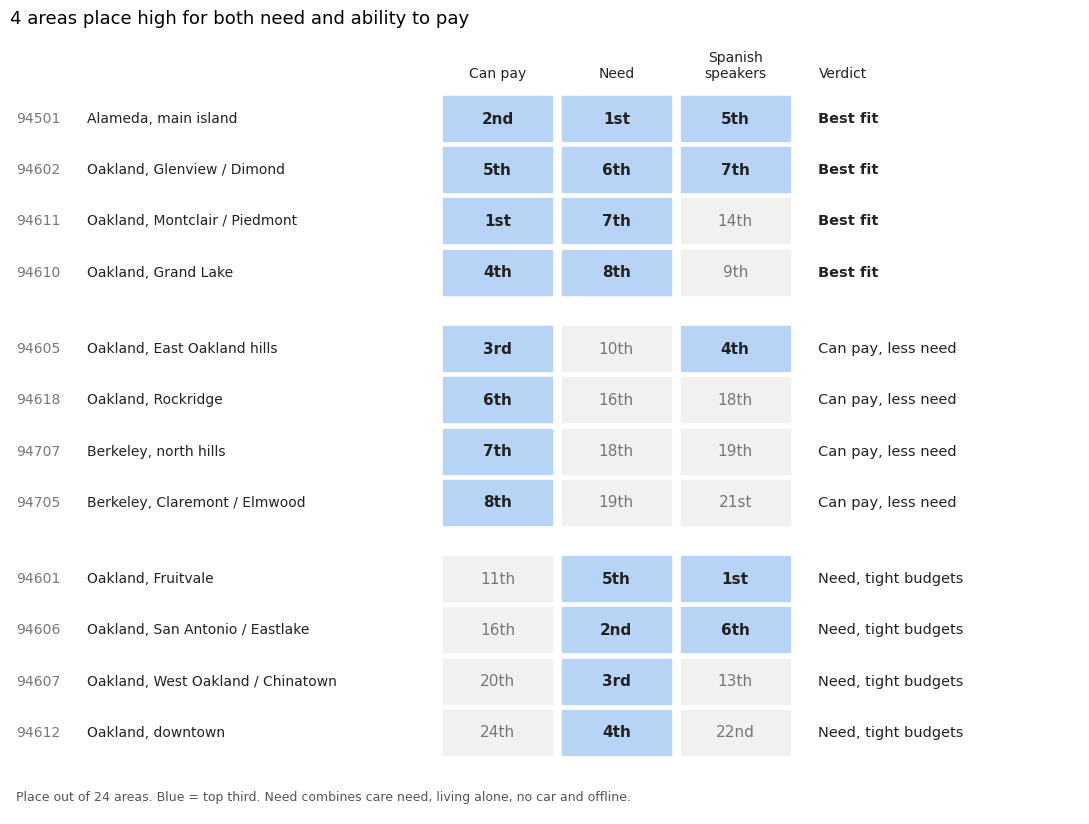

In [7]:
def ordinal(n):
    n = int(n)
    if 10 <= n % 100 <= 20:
        return f"{n}th"
    return f"{n}{ {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th') }"

columns = [("can_pay_place", "Can pay"), ("need_place", "Need"), ("spanish_place", "Spanish\nspeakers")]
groups = [(v, short[short["verdict"] == v]) for v in ORDER[:3]]

# Leave a gap between the three groups
positions, y = [], 0.0
for _, rows in groups:
    for z in rows.index:
        positions.append((z, y))
        y -= 1
    y -= 0.5
height = -y

fig, ax = plt.subplots(figsize=(11, 0.47 * height + 2.0))
for z, y in positions:
    row = short.loc[z]
    ax.text(-3.55, y, z, ha="left", va="center", fontsize=10, color="#777777")
    ax.text(-2.95, y, row["area"], ha="left", va="center", fontsize=10, color="#222222")
    for c, (col, _) in enumerate(columns):
        top = row[col] <= CUT
        ax.add_patch(plt.Rectangle((c + 0.04, y - 0.44), 0.92, 0.88, color="#b7d3f6" if top else "#f1f1ef"))
        ax.text(c + 0.5, y, ordinal(row[col]), ha="center", va="center", fontsize=11,
                fontweight="bold" if top else "normal", color="#222222" if top else "#777777")
    best = row["verdict"] == "Best fit"
    ax.text(3.2, y, row["verdict"], ha="left", va="center", fontsize=10.5, color="#222222", fontweight="bold" if best else "normal")
for c, (_, name) in enumerate(columns):
    ax.text(c + 0.5, 0.75, name, ha="center", va="bottom", fontsize=10, color="#222222")
ax.text(3.2, 0.75, "Verdict", ha="left", va="bottom", fontsize=10, color="#222222")
ax.text(-3.55, -height + 0.35, f"Place out of {N} areas. Blue = top third. Need combines care need, living alone, no car and offline.",
        ha="left", va="top", fontsize=9, color="#555555")
ax.set_xlim(-3.6, 5.4)
ax.set_ylim(-height - 0.1, 1.7)
ax.axis("off")
n_best = (s["verdict"] == "Best fit").sum()
ax.set_title(f"{n_best} areas place high for both need and ability to pay", fontsize=13, loc="left")
plt.tight_layout()
fig.savefig("../outputs/scorecard.png", dpi=150)
plt.show()

## 7. What I decided

- **Where I start outreach:** the four best-fit areas: Alameda's main island, Glenview / Dimond, Montclair / Piedmont and Grand Lake. The East Oakland hills come next, as a near miss that also ranks 4th for Spanish speakers.
- **Where I pitch assistant-type help:** Rockridge, the Berkeley north hills and Claremont / Elmwood.
- **What I do about areas with need but tight budgets:** They are not part of my launch. Income is only part of the picture, so before deciding I want to look at assets and savings as well.
- **How I will check this against real life:** Talk with senior center staff, hospital discharge planners and adult children of older parents in the best-fit areas, and track where my first clients come from.

### Limits to remember
- Places are based on counts, so bigger areas place higher. A small area can still be a good fit.
- "Top third" is my cutoff. Section 3 lists the near misses.
- The weights in section 4 are my judgment. The order below first place changes with them, which is why the verdicts use need and ability to pay side by side.
- Everything here comes from Census survey estimates of where people live. It does not show who wants to hire a helper. Conversations with real families are the next test.